In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [15]:
titanic=sns.load_dataset("titanic")

features=["pclass", "sex", "fare", "embarked", 'age']
target=["survived"]

#hanld Missing Values
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])


#Label Encoding
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

X=titanic[features]
y=titanic["survived"]

#Train test split
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.3, random_state=42
)

In [16]:
#Decision Tree Model-no pruning

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

print("Training accuracy:", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy:", accuracy_score(y_test, y_pred_test)*100, "%")

#case of overfitting

Training accuracy: 97.91332263242376 %
Testing accuracy: 77.23880597014924 %


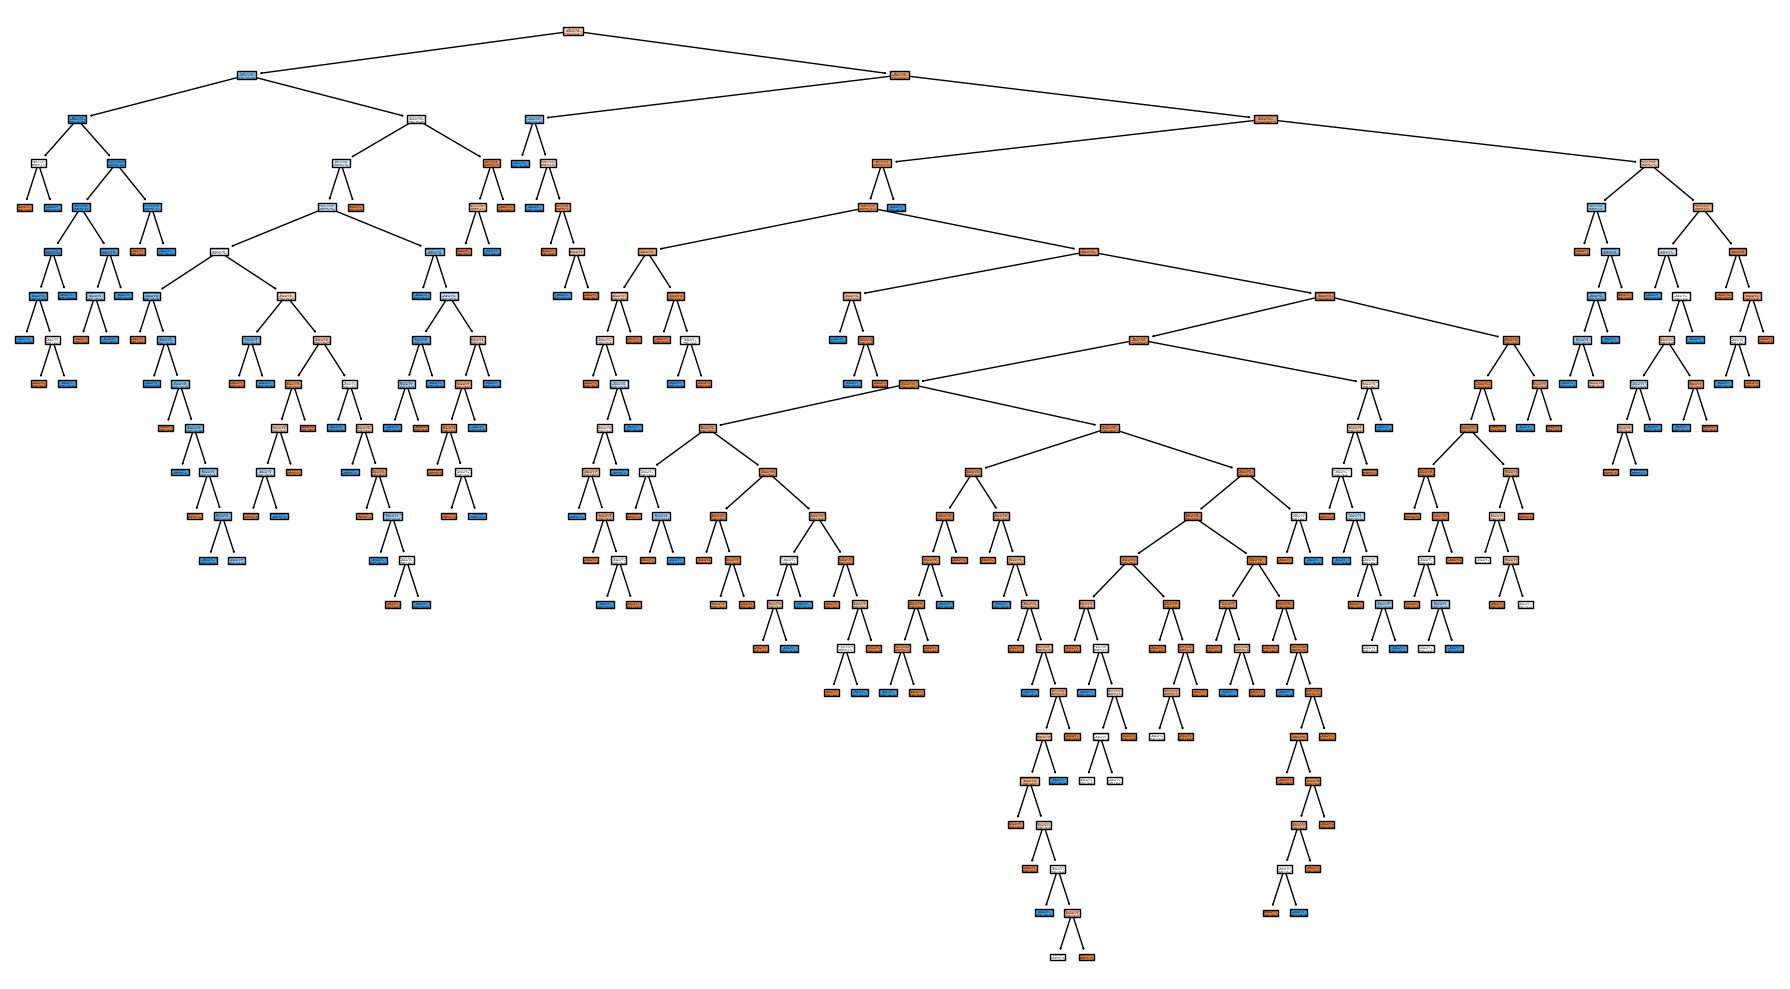

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True


    
)

plt.tight_layout()
plt.show()

In [28]:
#Implementing RandomForest

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=701,
    oob_score=True,
    max_depth=4
)
rf.fit(X_train, y_train)
y_pred=rf.predict(X_test)

print("OOB Score:", rf.oob_score_ * 100, "%")
print("testing accuracy:", accuracy_score(y_test, y_pred)* 100,"%")

OOB Score: 82.02247191011236 %
testing accuracy: 81.34328358208955 %


In [30]:
#Bagging Classifier
from sklearn.ensemble import BaggingClassifier
base_model=DecisionTreeClassifier()

bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred_test=bagging.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred)* 100,"%")

accuracy: 81.34328358208955 %


In [33]:
from sklearn.linear_model import LogisticRegression
base_model=LogisticRegression(max_iter=1000)

bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred=bagging.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred)* 100,"%")

accuracy: 79.47761194029852 %
